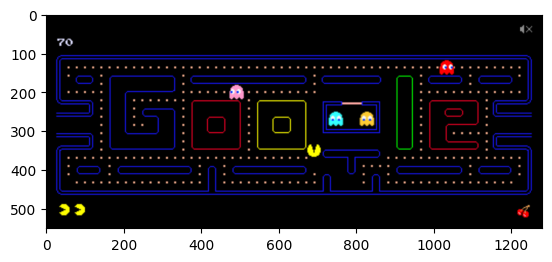

In [14]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

maze_bgr = cv.imread("./tests_folder/ingamecapture.png")
plt.imshow(maze_bgr[:,:,::-1])

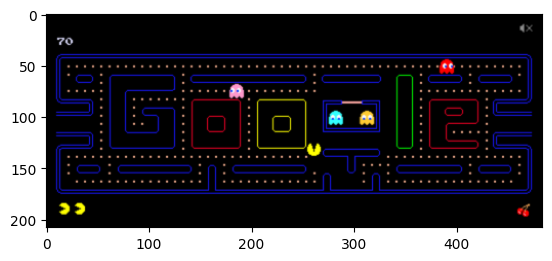

In [15]:
maze_reduced = cv.resize(maze_bgr, (484, 208), interpolation=cv.INTER_AREA)
plt.imshow(maze_reduced[:,:,::-1])

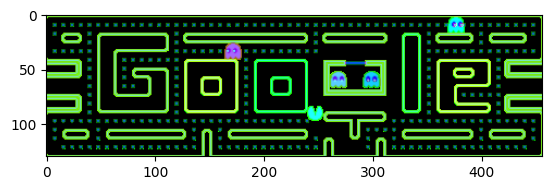

In [16]:
maze_croped = maze_reduced[42:172,14:470].copy() 
maze_hsv = cv.cvtColor(maze_croped, cv.COLOR_BGR2HSV)
plt.imshow(maze_hsv)

Voici les noms et surnoms des fantômes dans Pac-Man :

    Shadow (Ombre) - Blinky : le fantôme rouge.
    Speedy (Rapide) - Pinky : le fantôme rose.
    Bashful (Timide) - Inky (ou encore Inkey) : le fantôme bleu.
    Pokey (Limité) - Clyde : le fantôme orange.

Chaque fantôme a un comportement qui lui est propre :

    Blinky attaque directement Pac Man. Il suit Pac-Man comme son ombre.
    Pinky a tendance à se mettre en embuscade. Elle vise l'endroit où va se trouver Pac-Man.
    Inky est capricieux. De temps en temps, il part dans la direction opposée à Pac-Man.
    Clyde feint l'indifférence. De temps en temps, il choisit une direction au hasard (qui peut être celle de Pac-Man).

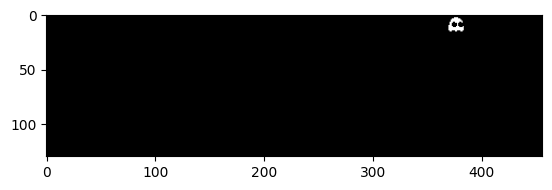

In [17]:
lower_red = np.uint8([0, 150, 200])  # 
upper_red = np.uint8([0, 255, 255])

blinky = cv.inRange(maze_hsv, lower_red, upper_red)
plt.imshow(blinky, cmap="gray")

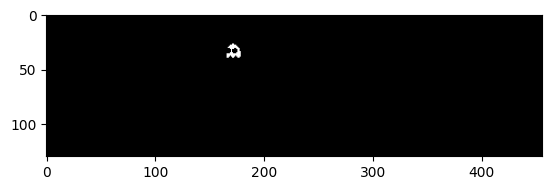

In [18]:
lower_pink = np.uint8([165, 30, 220])  # 
upper_pink = np.uint8([165, 255, 255])

pinky = cv.inRange(maze_hsv, lower_pink, upper_pink)
plt.imshow(pinky, cmap="gray")

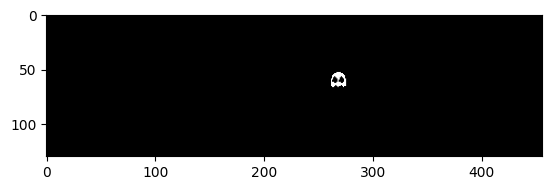

In [19]:
lower_blue = np.uint8([90, 50, 150])  # 
upper_blue = np.uint8([90, 255, 255])

inky = cv.inRange(maze_hsv, lower_blue, upper_blue)
plt.imshow(inky, cmap="gray")

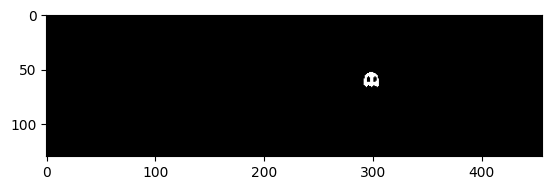

In [20]:
lower_orange = np.uint8([22, 50, 150])  # 
upper_orange = np.uint8([23, 255, 255])

clyde = cv.inRange(maze_hsv, lower_orange, upper_orange)
plt.imshow(clyde, cmap="gray")

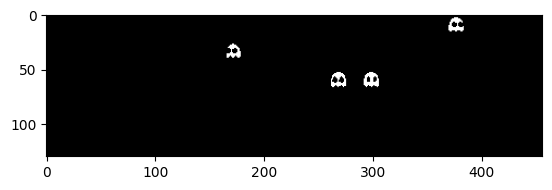

In [21]:
combinedMask = blinky | pinky | inky | clyde
plt.imshow(combinedMask, cmap="gray")

292 53 14 14
(295, 56)
262 53 14 14
(265, 56)
166 27 13 13
(169, 30)
370 3 14 13
(373, 6)


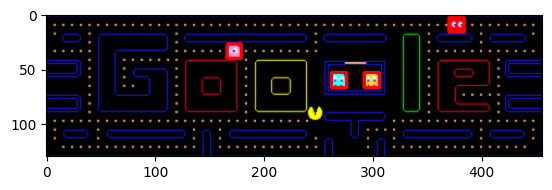

In [22]:
cnts,hierarchy = cv.findContours(combinedMask,cv.RETR_EXTERNAL,cv.CHAIN_APPROX_SIMPLE)
sorted(cnts, key=cv.contourArea, reverse=True)
displayGhostsBox = maze_croped.copy()


#cv.drawContours(displayGhostsBox, cnts, -1, (255,0,0), 1)

for cnt in cnts:
    x,y,w,h = cv.boundingRect(cnt)
    cv.rectangle(displayGhostsBox,(x,y),(x+w,y+h),(0, 0, 255),2)
    print(x, y, w, h)
    print((x + w//4, y + h//4))

    


plt.imshow(displayGhostsBox[:,:,::-1])


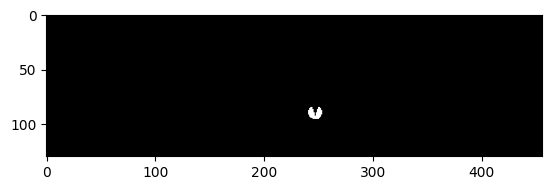

In [43]:
lower_yellow = np.uint8([25, 25, 198])  
upper_yellow = np.uint8([35, 255, 255])

pacman = cv.inRange(maze_hsv, lower_yellow, upper_yellow)
plt.imshow(pacman, cmap="gray")

In [44]:
cnts,hierarchy = cv.findContours(pacman,cv.RETR_LIST,cv.CHAIN_APPROX_SIMPLE)
cnt = sorted(cnts, key=cv.contourArea)
x,y,w,h = cv.boundingRect(cnt[-1])
print(x, y, w, h)


241 85 13 11
